

# Big Ideas Simplex vs Graphical
### OPIM 5641 - Business Decision Modeling · Module2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/5_Simplex/0_BigIdeas_Simplex_vs_Graphical.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Big Ideas: Graphical vs. Simplex
-------------------------------
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

*See Hillier and Lieberman Chapter 4 for more details.*

Here's the question this whole unit answers: the graphical method is lovely, but it only works with **two** decision variables - so how do we solve the real problems with dozens or hundreds? That's **Simplex**. The trick is that it never wastes time wandering through the middle of the feasible region; it hops smartly from corner to corner, always uphill, until it can't do any better. Get the geometry first and the algebra stops being scary.

🔷 **The nugget:** Simplex only ever visits *corner points* - and it moves to a better adjacent corner each step. That's the whole algorithm in one sentence.

# The Essence of the Simplex Method (Geometric)
The simplex method is an *algebraic* procedure. However, it's underlying concepts are *geometric*. Understanding these concepts provides a strong intuitive feeling for how the simplex method operates and what makes it so efficient.

To illustrate the general geometric concepts, we shall use the Wyndor Glass Co example. Here is a refresher on the graphical method solution.

In [ ]:
from pylab import *

## Graphical Solution
Remember - it's all about corner point solutions! We tried them all until we found the optimal solution.

To refresh your memory, the model and graph are presented below.

The problem is to select values of $x_1$ and $x_2$ so as to:

Maximize $Z = 3x_1 + 5x_2$

subject to the restrictions (constraints):
* $\;x_1\quad\quad\;\;\;\; \leq 4 $
* $\quad\quad\;\; 2x_2\; \leq 12$
* $3x_1 + 2x_2\; \leq 18$


### Plot the Constraints

**Time Constraint #1** ($X_1 \leq 4$)

This is just a vertical line. We will plot as a black line.

**Time Constraint #2** ($2X_2 \leq 12$)

This is just a horizontal line. We will plot as an orange line.

**Time Constraint #3** ($3X_1 + 2X_2 \leq 18$)

We will plot this as a blue line.

This one is a little tough because it's a diagonal line, but go back to your grade school math class and solve an inequality!

* $3X_1 + 2X_2 <= 18$ `Time Constraint 3)`
  * when $X_1 = 0$, $X_2 = 18/2 = 9$
  * when $X_2 = 0$, $X_1 = 18/3 = 6$
    * Plot the coordinates ($X_1$=0, $X_2$=9) and ($X_1=6$, $X_2=0$) and draw a line between them

### Identify Corner Points

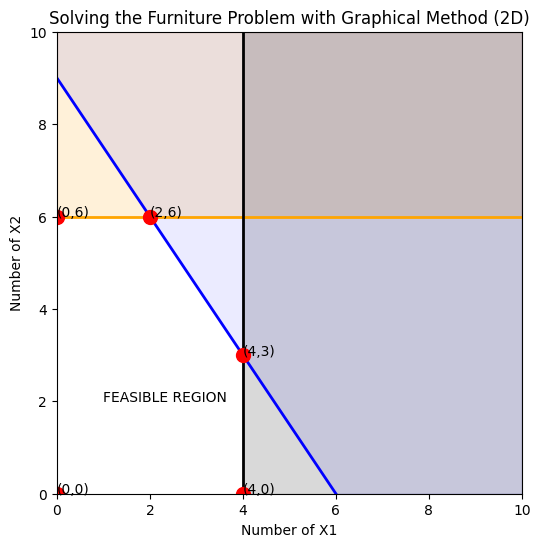

In [ ]:
figure(figsize=(6,6)) # this makes the image nice and big! try 5,5 or 10,10 if you want
axis([0,10,0,10]) # these are the limits for x and y (xmin, xmax, ymin, ymax).
xlabel('Number of X1') # ALWAYS add pretty titles (xlabel, which we've decided to be tables)
ylabel('Number of X2') # ALWAYS add pretty titles (ylabel, which we've decided to be chairs)


# horizontal constraint
x = array([0, 10])
y = array([6, 6])
plot(x, y,'orange',lw=2) # the lw=2 argument makes a line
fill_between(x=[0, 10], # x area
             y1=[6, 6], # y1 area (lower end of curve) - shade above here!
             y2=[10, 10], # y2 area (upper end of curve) - shade below here!
             color='orange', # color
             alpha=0.15) # transparency

# vertical constraint
x = array([4, 4])
y = array([0, 10])
plot(x, y,'black',lw=2)
fill_between(x=[4, 10],
             y1=[0,0],
             y2=[10,10],
             color='black',
             alpha=0.15)

# diag constraint
# 3X1 + 2X_2 = 18
x = array([0, 6]) # X1
y = array([9, 0]) # X2
plot(x, y,'blue',lw=2)
# this the right way with three arguments to x, y1 and y2
fill_between(x=[0,6,10],
             y1=[9,0,0],
             y2=[10,10,10],
             color='blue',
             alpha=0.08)

# bells and whistles
title('Solving the Furniture Problem with Graphical Method (2D)')
text(x=1,y=2,s='FEASIBLE REGION')

# Corner points
plot(0,0,'r.',ms=20) # makes a red dot on the plot
annotate('(0,0)', xy=(0,0), xytext=(0,0)) # adds a label

plot(0,6,'r.',ms=20) # makes a red dot on the plot
annotate('(0,6)', xy=(0,6), xytext=(0,6)) # adds a label

plot(2,6,'r.',ms=20) # makes a red dot on the plot
annotate('(2,6)', xy=(2,6), xytext=(2,6)) # adds a label

plot(4,3,'r.',ms=20) # makes a red dot on the plot
annotate('(4,3)', xy=(4,3), xytext=(4,3)) # adds a label

plot(4,0,'r.',ms=20) # makes a red dot on the plot
annotate('(4,0)', xy=(4,0), xytext=(4,0)) # adds a label

show()

### Identify Corner Points
Starting in the bottom left:
0. (0,0) is the first corner point and is immediately identifiable
1. (0,6) is the second corner point and is also easily read
2. (2,6) is the third corner point, but requires some algebra to solve for the intersection of the two points.



 * Constraint 2 is the orange line on the graph and is given by $2X_2 \leq 12$
 * Constraint 3 is the blue line on the graph is given by $3X_1 + 2X_2 \leq 18$

 * Typically, we need to subtract these two equations and get rid of a variable, then plug it back in to calculate the other variable.

* First, turn the inequalities into equal signs.
  * $2X_2 = 12$
  * $3X_1 + 2X_2 = 18$

* But since one of the equations only has a single variable, plug it in and find that $X_2 = 6$, which means we can plug it back in and find $X_1 = 2$

3. (4,3) is the third corner point, but requires some algebra to solve for the intersection of the two points.

 * Constraint 1 is the black line on the graph and is given by $X_1 \leq 4$
 * Constraint 3 is the blue line on the graph is given by $3X_1 + 2X_2 \leq 18$
  * Since we already know $X_1$, this one isn't too tough to solve - plug and chug and solve for $X_2$!
  * $3*4 + 2X_2 = 18$ means $2X_2 = 6$ therefore $X_1 = 3$.

4. (4,0) is the last corner point and can be read from the graph.

### Evaluate Corner Points
After evaluating all possible values, we find that (2,6) maximizes the objective function and yields $Z=36$.

## Key Concepts of Graphical Method
* For a linear programming problem with $n$ decision variables, each of the corner points lies at the intersection of $n$ constraint boundaries.
* For any linear programming problem with n decision variables, two CPF solutions are **adjacent** to each other if they share $n-1$ constraint boundaries. The two adjacent CPF solutions are connected by a line segment that lies on these same shared constraint boundaries, known as **edges** of the feasible region.
* **Optimality test**: Consider any linear programmng problem that posseses at least one optimal solution. If a CPF solution has no adjacent CPF solutions that are *better* (as measured by $Z$), then it must be an *optimal solution*.

**Table:** Adjacent CPF solutions for each CPF solution of the Wyndor Glass Co. problem


CPF solution| Its adjacent CPF solutions
---|---
(0,0)|(0,6) and (4,0)
(0,6)|(2,6) and (0,0)
(2,6)|(4,3) and (0,6)
(4,3)|(4,0) and (2,6)
(4,0)|(0,0) and (4,3)

🔷 Go look at the table and ensure that you can make this table from scratch!



# Solving the Example (the Geometry of Simplex)
Here is an outline of what the simplex method does (from a geometric viewpoint) to solve Wyndor Glass. At each step, first the conclusion is stated and then the reasoning in parentheses.

* **Initialization:** Choose (0,0) as the *initial* CPF solution to examine. (This is convenient because no caluclations are required to identify this CPF solution.)
* **Optimality Test:** Conclude that (0,0) is not an optimal solution. (Adjacent CPF solutions are better.)
* **Iteration 1:** Move to a better *adjacent* CF solution, (0,6), by performing the following three steps.
  1. Choose to move alongthe $x_2$ axis. (With our objective function $Z = 3x_1 + 5x_2$, moving up $x_2$ increases $Z$ at a faster rate).
  2. Stop a the first new constraint boundary: $2x_2 = 12$ (Moving any farther would leave the constraint boundary).
  3. Solve for the intersection of the new set of constraint boundaries (0,6).

* **Optimality Test:** Conclude that (0,6) is not an optimal solution. (An adjacent CPF solution is better.)

* **Iteration 2:** Move to a better adjacent CPF solution (2,6) by following these three steps:
  1. Considering two edges of the feasible region that emanate from (0,6) choose to move along the edge that leads to the right. (Moving along this edge increases $Z$ whereas backtracking would decrease $Z$)
  2. Stop at the new constraint boundary: $3x_1 + 2x_2 =18$. (Moving any further would leave the feasible region.)
  3.Solve for the intersection of the new boundaries and get (2,6)

* **Optimality Test:** Conclude that (2,6) is  an optimal solution. (An adjacent CPF solution is NOT better!) You are done!

# Key Solution Concepts (Simplex)
Here are six key solution concepts to keep in mind.

1. **The simplex method focuses solely on CPF solutions.** For any problem with at least one optimal solution, finding one only requires finding a best CPF solution.
  * Since the number of feasible solutions are generally infinite, reducing the number of solutions to a small finite number is a tremendous simplification.
  * 🔴 you will see that there are plenty of corner point INFEASIBLE solutions... we simply ignore them!
2. The simplex method is an *iterative algorithm* (a systematic solution procedure that keeps repeating a fixed series of steps, called an *iteration*, until a desired result has been obtained) with the follwing steps:
  * **Initialization:** set up to start iterations, including finding an initial CPF solution.
  * **Optimality test:** is the current CPF solution optimal? If yes, stop. If no, perform an iteration to find a better CPF solution.
3. Whenever possible, **the initialization of simplex chooses the origin** (all decision variables equal to zero) to be the **initial CPF solution**. If not possible, special procedures are required.
4. Given a CPF solution, it is much quicker computationally to gather information about **adjacent CPF solutions** than other CPF solutions. Hence, we always **follow the edges of the feasible region**.
5. When identifying adjacent CPF solutions, one could be tempted to solve for the values. But this isn't strictly required. **You can just look at the slope and determine if there is a rate of improvement or not**.
  * A positive rate of improvement means that the adjacent CPF is better than the current one. If no positive rate of improvement exists, you are optimal!

# Setting Up The Simplex Method (Algebraic)
While there is certainly a geometric interpretation of simplex, computers can only handle algebraic instructions. So let's transform this geometric procedure into a useable algebraic procedure.

The algebraic procedure is based on solving a system of equations. First, let's make sure the problem is in **standard form** (all less than or equal to (LEQ) constraints and a maximization problem - more on this later.) Therefore, the first step is to convert the functional *inequality constraints* into equivalent *equality constraints* (everything except the nonnegativity constraints). The conversion is accomplished by introducing **slack variables**.



## Slack variables for the first constraint
Consider the first function constraint from Wyndor...

$x_1 \leq 4$

The slack variable for this constraint is $x_3$

$x_3 = 4 - x_1$

The slack is the amount leftover! It's the amount leftover on the lefthand side of the inequality. It's the unused portion.  Thus,

$x_1 + x_3 = 4$

Given this equation, $x_1 \leq 4$ if and only if $4 - x_1 = x_3 \geq 0$. Therefore, the original constraint $x_1 \leq 4 $ is entirely equivalent to this pair of constraints

$x_1 + x_3 = 4$ and $x_3 \geq 0$

## Create the augmented form of the model
Upon the introduction of slack variables for the other functional constraints, the original linear programming model can now be replaced by the equivalent model (called the *augmented form* of the model).

### Original Form of the Model
Maximize $Z = 3x_1 + 5x_2$

subject to:
* $\;x_1\quad\quad\;\;\;\; \leq 4 $
* $\quad\quad\;\; 2x_2\; \leq 12$
* $3x_1 + 2x_2\; \leq 18$

and
* $x_1 \geq 0$ and $x_2 \geq 0$

### Augmented Form of the Model
Maximize $Z = 3x_1 + 5x_2$

subject to:

* $\;x_1\quad\quad\;\;\;\; + x_3 \quad\quad\quad\quad\quad = 4 $
* $\quad\quad\;\; 2x_2\; \quad\quad\quad + x_4 \quad\quad = 12$
* $3x_1 + 2x_2\;\quad\quad\quad\quad\quad +x_5 = 18$

and
* $x_j \geq 0$ for $j = 1, 2, 3, 4, 5$

🔷 do you see how nice it is when everything lines up with one variable for one column? This is a lot of work to do (double click to see) but it is worth it.

Although both forms of the model represent exactly the same problem, the new form is much more convenient for algebraic manipulation. We call this the **augmented form** of the problem because the original form has been *augmented* by some supplementary variables needed to apply the simplex method.

If a slack variable equals 0 in the current solution, then this solution lies on the constraint boundary for the corresponding functional constraint. A value greater than 0 means that the solution lies on the feasible side of the constraint boundary; whereas a value less than 0 means that the solution lies on the infeasible side of the constraint boundary.

# Important Terminology (augmented form)
Here is corresponding terminology for augmented form.

* An **augmented solution** is a solution for the original variables (the decision variables) that has been augmented by the corresponding values of the slack variables.

For example, augmenting the solution (3,2) in the example yields the augmented solution (3,2,1,8,5) because the corresponding values of the slack variables are $x_3 = 1$, $x_4 = 8$ and $x_5 = 5$.

* A **basic solution** is an augmented corner-point solution. It can be feasible or infeasible.
* A **basic feasible (BF) solution** is an augmented CPF solution.

The only difference between basic solutions and corner-point solutions (or between BF solutions and CPF solutions) is whether the values of the slack variables are included.


## Degrees of freedom
For the augmented form of the example, notice that the system of functional constraints has 5 variables and 3 equations, so...

Number of variables - number of equations = $5-3=2$

This fact gives us 2 *degrees of freedom* in solving the system, since any two variables can be chosen to be set equal to any arbitrary value in order to solve the three equation in terms of the other variables. **The simplex method uses 0 for this arbitrary value**.

Thus, two of the variables (called the **nonbasic variables**) are set equal to zero, and then the simultaneous solution of the three other equations for three other variables (called the basic variables) is a **basic solution**.

## Basic solutions
🔷 Just because it is a basic solution doesn't mean it's optimal!

A **basic solution** has the following properties:
1. Each variable is designated as either a **nonbasic variable** or a **basic variable**.
2. The **number of basic variables equals the number of functional constraints** (now equations). Therefore, the number of nonbasic variables equals the total number of variables minus the number of functional constraints.
3. The **nonbasic variables** are set equal to zero.
4. The values of the **basic variables** are obtained as the simultaneous solution of the system of equations (functional constraints in augmented form).
5. If the basic variables satisfy the nonnegativity constraints, the basic solution is a BF solution.

# The Algebra of the Simplex Method
We can now sketch a conceptual outline of the simplex method from either a geometric or algebraic perspective.

## Conceptual Outline of the Simplex Method
1. **Perform initialization** to identify the initial solution for starting the simplex method.
2. **Apply the optimality test** to determine if the current solution is optimal.
  a. if so, stop.
  b. if not, perform an iteration.
3. **Step 1 of an iteration:** Determine which direction in which to move to get to the next solution.
4. **Step 2 of an iteration:** Determine where to stop to reach this next solution.
5. **Step 3 of an iteration:** Solve for this new solution.
6. **Return to the optimality test.**

## Initialization


The choice of $x_1$ and $x_2$ to be the **nonbasic variables** (the variables set equal to zero) for the initial BF solution is related to Key Solution 3 above ('Whenever possible, the initialization of simplex chooses the origin (all decision variables equal to zero) to be the initial CPF solution'.)

This choice eliminates the work required to solve for **basic variables** ($x_3$, $x_4$, $x_5$) from the following system of equations:

1. $\;x_1\quad\quad\;\;\;\; + x_3 \quad\quad\quad\quad\quad = \;4 $
2. $\quad\quad\;\; 2x_2\; \quad\quad\quad + x_4 \quad\quad = 12$
3. $3x_1 + 2x_2\;\quad\quad\quad\quad\quad +x_5 = 18$

$x_1=0$ and $x_2 = 0$ so...
* $x_3 = 4$
* $x_4 = 12$
* $x_5 = 18$

Thus, the **initial BF solution** is (0, 0, 4, 12, 18).

🔷 Note this solution can be read immediately because each equation has just one basic variable, which has a coefficient of 1, and this basic variable does not appear in any other equation!

When the set of basic variables changes, the simplex method uses an algebraic procedure (Gaussian elimination) to convert the equation to something just as easy to read. This form is called **proper form of Gaussian elimiation**.

## Optimality Test
The objective function is:
$Z = 3x_1 + 5x_2$ so $Z=0$ is the initial BF solution.

Because none of the basic variables ($x_3$, $x_4$, $x_5$) have a nonzero coefficient in this objective function, the coefficient of each nonbasic variable ($x_1$, $x_2$) gives us the rate of improvement of $Z$ if that variable were to be increased from zero (while the values of the basic variables are adjusted to continue satisfying the system of equations).

The rates of improvement ($3$ and $5$) are *positive*. Therefore, we conclude that $(0,0,4,12,18)$ is not optimal.

For each BF solution examined after subsequent iterations, at least one basic variable has a nonzero coefficient in the objective function. Therefore, the optimality test will rewrite the objective function in terms of *just the nonbasic variables*. More soon.

## Determining the Direction of Movement (Step 1 of an Iteration)
Increasing one nonbasic variable (while adjusting basic variables to continue satisfying the system of equations) corresponds to moving along one edge emanating from the current CPF solution. Based on Key Concepts 4 and 5 above, the choice of which nonbasic variable to increase is made as follows:

* $Z = 3x_1 + 5x_2$
* Increase $x_1$? Rate of improvement in $Z=3$
* Increase $x_2$? Rate of improvement in $Z=5$

$5>3$ so choose $x_2$ to increase. We call $x_2$ the *entering basic variable* for iteration 1.


> At any iteration of the simplex method, the purpose of Step 1 is the choose one nonbasic variable to increase from zero (while the values of the basic variables are adjusted to continue satisfying the system of equations.) Increasing this nonbasic variable from zero will convert it to a basic variable for the next BF solution. Therefore, this variable is called the **entering basic variable** for the current iteration (because it is entering the basis).









## Determining Where to Stop (Step 2 of an Iteration - minimum ratio test)
Can try to add `^*` to the basic variables so these are very obvious!

Step 2 addresses the question of how far to increase the entering basic variable $x_2$ before stopping. Increasing $x_2$ increases $Z$, so we want to go as far as possible without leaving the feasible region.

However, increasing $x_2$ will change the values of some of the basic variables as shown below.

1. $\;x_1\quad\quad\;\;\;\; + x_3 \quad\quad\quad\quad\quad = \;4 $
2. $\quad\quad\;\; 2x_2\; \quad\quad\quad + x_4 \quad\quad = 12$
3. $3x_1 + 2x_2\;\quad\quad\quad\quad\quad +x_5 = 18$

$x_1=0$ and $x_2$ is going to increase to some nonnegative value, so...
* $x_3 = 4$
* $x_4 = 12 - 2x_2$
* $x_5 = 18 - 2x_2$

The other requirement for feasibility is that all the variables be *nonnegative*. The non-basic variables (including the entering basic variable) are nonnegative, but we need to check how far $x_2$ can be increased without violating the nonnegativity constraints for the basic variables.

* $x_3 = 4 \geq 0$ hence no upper bound on $x_2$
* $x_4 = 12 - 2x_2 \geq 0$ hence $x_2 \leq \frac{12}{2} = 6$ $\leftarrow$ minimum!
* $x_5 = 18 - 2x_2 \geq 0$ hence $x_2 \leq \frac{18}{2} = 9$

Remember, when you divide both sides by a negative number, [the sign of the inequality reverses](https://www.khanacademy.org/math/cc-seventh-grade-math/cc-7th-variables-expressions/cc-7th-inequalities/v/inequalities-using-multiplication-and-division#:~:text=And%20remember%2C%20when%20you%20multiply,negative%200.5%20is%20just%201.)! Yes, if you look at the link, it says '7th grade math' 🐙

🔷 notice how we solved in terms of the basic variables... $x_3, x_4, x_5$

🔷 Thus, $x_2$ can be increased to just 6, at which point $x_4$ has dropped to 0. Increasing $x_2$ beyond 6 would cause $x_4$ to become negative which would violate feasibility.

Go look at the graphical solution above and see this for yourself!

These calculations are referred to as the **minimum ratio test**. The objective of this test is to determine which basic variable drops to zero first as the entering basic variable is increased. The basic variable in the equation with the minimum positive ratio is the one that drops to zero first as the entering basic variable is increased.



> At any iteration of the simplex method, step 2 uses the minimum ratio test to determine which basic variable drops to zero first as the entering basic variable is increased. Decreasing this basic variable to zero will convert it to a nonbasic variable for the next BF solution. Therefore, this variable is called the **leaving basic variable** for the current iteration (because it is leaving the basis).

Thus, $x_4$ is the leaving basic variable for iteration 1 of the example.



## Solving for the New BF Solution (Step 3 of an Iteration)
Increasing $x_2=0$ to $x_2 = 6$  moves us from the initial BF solution to the new BF solution.

. |Initial BF solution| New BF solution|
---|---|---|
Nonbasic variables| $x_1=0$ , $x_2=0$| $x_1 = 0$, $x_4 = 0$|
Basic variables|($x_3 = 4$, $x_4=12$, $x_5=18$)| ($x_3=?$, $x_2=6$, $x_5 = ?$)

Remember how easy it was to read off the basic variables from the initial BF solution? **Basic variables had a coefficient of one**. Now we have a different set of basic variables ($x_2$ is now basic!) so we have to do some **elementary algebraic operations** to make things more readable.

Here again is the complete original system of equations, where the *new* basic variables are shown (with $Z$ playing the role of the basic variable in the objective function).

0. $Z \quad -3x_1 - 5x_2 \quad\quad\quad\quad\quad\quad\quad\;= \;0$
1. $\quad\quad\quad\;x_1\quad\quad\;\;\;\; + x_3 \quad\quad\quad\quad\quad = \;4 $
2. $\quad\quad\quad\quad\quad\;\; 2x_2\; \quad\quad\quad + x_4 \quad\quad = 12$
3. $\quad\quad\quad3x_1 + 2x_2\;\quad\quad\quad\quad\quad +x_5 = 18$

Thus, $x_2$ has replaced $x_4$ as the basic variable in Eqn (2). To solve this system of equations for $Z, x_2, x_3, x_4$ we need to perform some elementary algebraic operations to reproduce the current pattern of coefficients (0,0,1,0) as the new coefficients of $x_2$ - the new basic variable!
🔷 The basic variables should only be in one equation and have a coefficient of 0. The main purpose of this is for readability so we can quickly read off the solution and move on.

We can use two types of elementary algebraic operations:
1. Multiply (or divide) an equation by a nonzero constant
2. Add (or subtract) a multiple of one equation to (or from) another equation

Elementary row operations are simple operations that allow us to transform a system of linear equations into an equivalent system, that is, into a new system of equations having the same solutions as the original system.

More here on the math:
* https://www.math.ucdavis.edu/~linear/old/notes3.pdf
* https://www.statlect.com/matrix-algebra/elementary-row-operations

To prepare for performing these operations, note that the coefficients of $x_2$ in the above equations are -5, 0, 2 and 2, respectively, whereas we want these coefficients to become 0, 0, 1, and 0, respectively.

Let's start by getting the '1'. To turn the coefficient of 2 in Eqn 2. into a 1, we use the first type of elementary algebraic operation by dividing the Eqn (2) by a 2 to obtain

$x_2 + \frac{1}{2}x_4 = 6$ (new Eqn 2)

Look above to see that we just divided Eqn 2 by 2! These equation is the same just transformed for readability. Now it's clear that when $x_2=6$ that $x_4$ must be 0. This is great!

As a rule, we know that basic variables like $x_2$ should only be in one equation. Now we need to get rid of the $x_2$ from the other equations. We do this by using the second type of row operations.

In particular, **we add 5 times this new Eqn (2) to Eqn (0) and subtract 2 times Eqn (2) from Eqn (3)**. The resulting complete new system of equations is:

0. $Z \quad -3x_1 \quad\quad\quad\quad\quad\;+ \frac{5}{2}x_4 \quad\quad= 30$
1. $\quad\quad\quad\;x_1\quad\quad\;\;\;\; + x_3 \quad\quad\quad\quad\quad = \;4 $
2. $\quad\quad\quad\quad\quad\;\; x_2\; \quad\quad\quad + \frac{1}{2}x_4 \quad\quad = \;6$
3. $\quad\quad\quad3x_1 \quad\quad\quad\quad\quad\quad\quad x_4 + x_5 = \;6$


Since $x_1=0$ and $x_4=0$ the equations in this form immediately yield the new BF solution $(x_1, x_2, x_3, x_4, x_5) = (0,6,4,0,6)$ which yields $Z=30$.

🔷 isn't the readability AWESOME! Practice this until it makes sense. You should be able to immediately yield the values of $x_2, x_3$ and $x_5$ (the basic variables) given your nonbasic variables $x_1, x_4$. Terminology and standardization are important!

This procedure for obtaining the simultaneous solution of a system of linear equations is called the Gauss-Jordan method of elimination, or **Gaussian elimination**. In the future we will say things like 'get a 1 in the pivot element and make everything else 0 above and below' when we start working with this in tabular form.


> The key concept for this method is the use of elementary algebraic operations to reduce the original system of equations to proper form from Gaussian elimination, where each basic variable has been eliminated from all but one equation (its equation) and has a coefficient of +1 in that equation.



## Optimality Test for the New BF Solution
The current Eqn (0) gives us the value of the objective function in terms of just the current nonbasic variables:

$Z = 30 + 3x_1 - \frac{5}{2}x_4$

Increasing either of these nonbasic variables from zero (while adjusting the values of the basic variables to continue satisfying the system of equations) would result in moving toward one of the two *adjacent* BF solutions. Because $x_1$ has a positive coefficient, increasing $x_1$ would lead to an adjacent BF solution that is better than the current BF solution, so the current solution is not optimal.

🔷 reflect on the concept of adjacent solutions - it's obvious in 2D, try to generalize to 3D, 5D, 10D... 100D!

## Iteration 2 and the Resulting Optimal Solution
### Step 1: Entering Variable
Since $Z=30 + 3x_1 - \frac{5}{2}x_4$, $Z$ can be increased by increasing $x_1$ but not $x_4$. Therefore, step 1 chooses $x_1$ to be the basic entering variable.

### Step 2: Min Ratio Test
For step 2, the current system of equations yields the following conclusions about how far $x_1$ can be increased (with $x_4 = 0$)

* $x_3 = 4 - x_1 \geq 0 ⇒ x_1 \leq \frac{4}{1} = 4$
* $x_2 = 6 \geq 0 ⇒ $ no upper bound on $x_1$
* $x_5 = 6 - 3x_1 \geq 0 ⇒ x_1 \leq \frac{6}{3} = 2 \leftarrow $ minimum!

Therefore, the minimum ratio test indicates that $x_5$ is the leaving basic variable and that we will make $x_1$ equal to 2.

### Step 3: GJ elimination
For step 3, with $x_1$ replacing $x_5$ as a basic variable, we perform elementary algebraic operations on the current system of equations to reproduce the current pattern of coefficients $x_5$ as the new coefficients of $x_1$. This yields the following new system of equations:

NEW:
0. $Z\;\;\;\quad\quad\quad\quad\quad\quad\quad\quad+ \frac{3}{2}x_4 + \;\; x_5= 36$
1. $\quad\quad\quad\quad\quad\quad\;\;\;\;\; x_3 \quad\;+\frac{1}{3}x_4 - \frac{1}{3}x_5 = \;2 $
2. $\quad\quad\quad\quad\quad\;\; x_2\; \quad\quad\quad + \frac{1}{2}x_4 \quad\quad\;\; = \;6$
3. $\quad\quad\quad x_1 \quad\quad\quad\quad\quad\;\; -\frac{1}{3} x_4 + \frac{1}{3}x_5 = \;2$

Therefore, the next BF solution is $(x_1, x_2, x_3, x_4, x_5) = (2,6,2,0,0)$ which yields $Z=36$.

To apply the optimality test to this new BF solution, we use the current Eqn (0) to express Z in terms of just the current nonbasic variables:

$Z = 36 - \frac{3}{2}x_4 - x_5$

Increasing $x_4$ or $x_5$ would decrease Z, so neither adjacent BF solution is as good as the current one.

Therefore, based on the Key Solution Concept 5, the current BF solution must be optimal.

🔷 do you see any positive coefficients in the above eqn? No! You couldn't possible improve Z. So you are done.

# On your own
Go work through all of this with pencil and paper and make sure your math lines up with this notebook!

# Resources
*
Spacing help... $\LaTeX$
* https://tex.stackexchange.com/questions/74353/what-commands-are-there-for-horizontal-spacing

## Bottom line

- The graphical method and Simplex find the *same* optimum - Simplex is just the algebra that scales past two variables.
- Every step: pick an **entering** variable (improves Z), a **departing** variable (the min-ratio test), pivot, repeat until no improvement is possible.
- The objective function lives in the **bottom row** of the tableau - keep it there.

**Take it further:** we grind these tiny examples by hand so the mechanics stick, but real problems go to a solver. Once you trust the by-hand steps, jump to the Pyomo notebooks and let the computer pivot for you - same logic, thousands of variables.

*Next: we'll drill the exact tableau steps for maximization, then minimization.*